In [14]:
import pandas as pd

df = pd.read_pickle('../data-reeval-multi/calibration_results_lada_joint.pkl')

# Extract combined_data rows before filtering
df_combined = df[df['scenario'] == 'combined_data'].copy()

# IRT values are now already included in the pickle file

In [ ]:
# Check the dataframe structure
print("DataFrame shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nScenarios with missing size:")
print(df[df['size'].isna()]['scenario'].unique())

# Check available K factors
print("\nAvailable K factors in data:")
print(sorted(df['k_factor'].unique()))
print("\nK factor distribution:")
print(df['k_factor'].value_counts().sort_index())

# Verify best K selection for a few scenarios
print("\nExample: lsat_qa K-factors and their AUCs:")
if 'lsat_qa' in df['scenario'].values:
    lsat_data = df[df['scenario'] == 'lsat_qa'][['k_factor', 'test_auc']].sort_values('test_auc', ascending=False)
    print(lsat_data)

DataFrame shape: (69, 9)

Columns: ['scenario', 'k_factor', 'test_auc', 'aic', 'bic', 'best_epoch', 'log_likelihood', 'size', 'irt']

First few rows:
                 scenario  k_factor  test_auc            aic            bic  \
0  entity_data_imputation         3  0.978713   11592.147461   28539.913220   
1         entity_matching         3  0.949693   47313.957031  103878.129667   
2                    imdb         3  0.942153   80898.878906  225655.378798   
3             commonsense         3  0.927607   23102.589844   44696.852934   
4          air_bench_2024         3  0.920770  144221.476562  349206.078328   

   best_epoch  log_likelihood    size       irt  
0         100    -3667.073730   395.0  0.934480  
1         119   -17523.978516  1396.0  0.886959  
2          66   -25780.439453  3530.0  0.882950  
3          85    -9010.294922   498.0  0.920394  
4          69   -51621.738281  4985.0  0.903832  

Scenarios with missing size:
['combined_data']


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_19584/1809823902.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


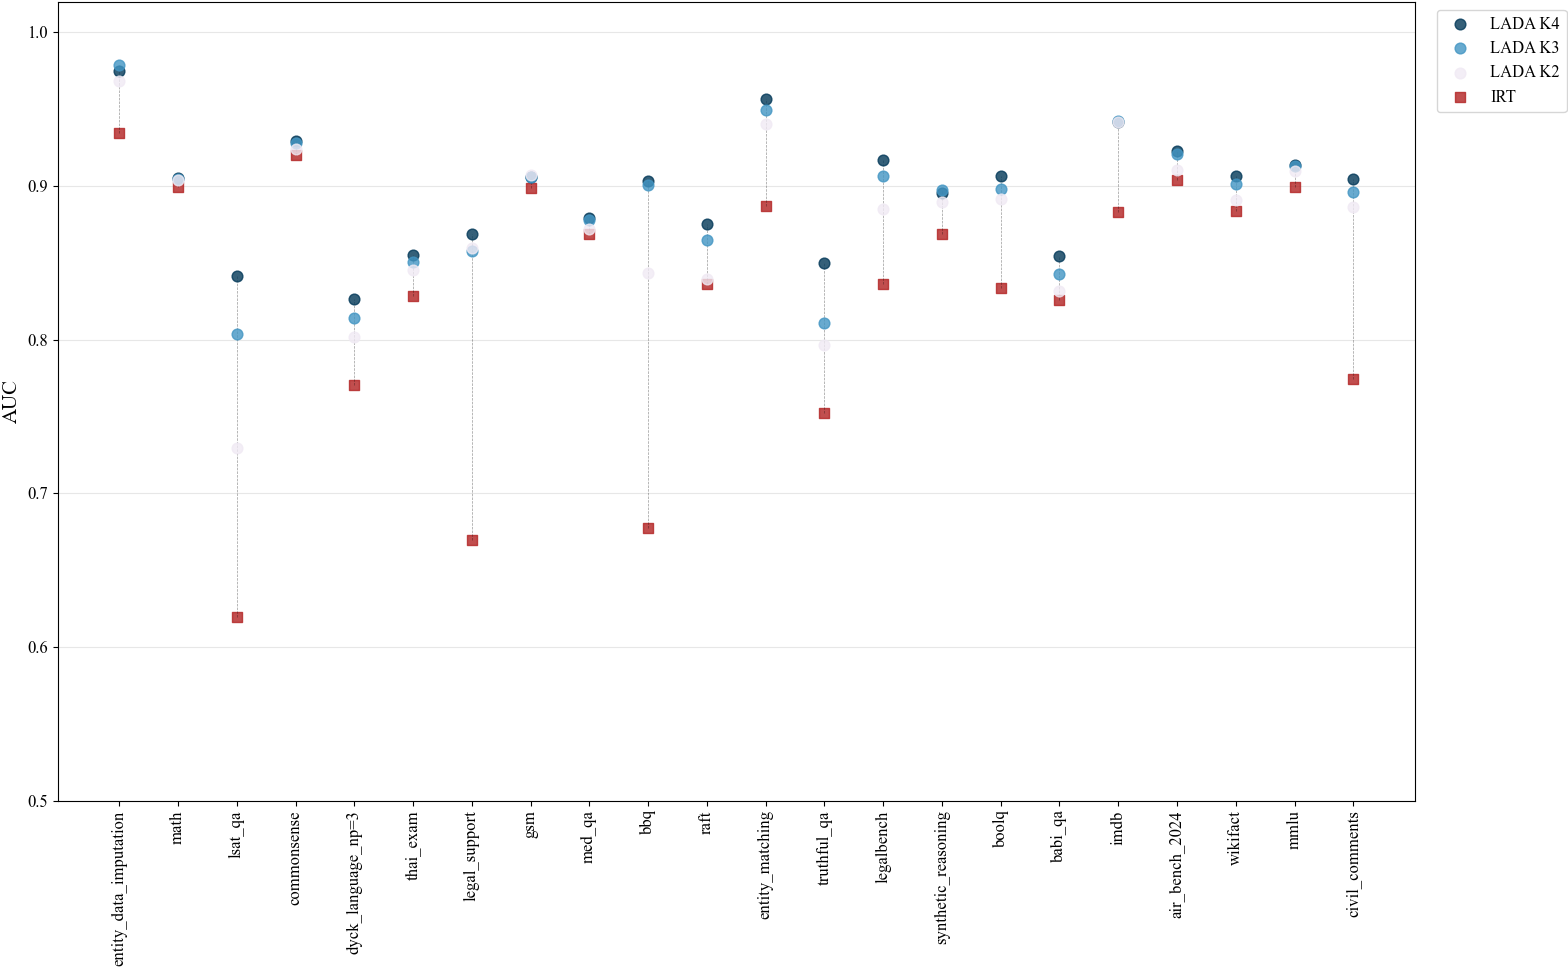

In [16]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Filter out rows with missing size values
df_plot = df.dropna(subset=['size']).copy()

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df_plot.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df_plot['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df_plot['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df_plot[df_plot['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the LADA points
	ax.scatter(x_positions, df_k['test_auc'], 
			  color=color_map[k_factor], s=60, 
			  label=f'LADA K{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario
df_irt = df_plot.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df_plot[df_plot['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and LADA) for this scenario
	all_values = list(df_scenario['test_auc']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.5, 1.02)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# import matplotlib.pyplot as plt
# import sys
# sys.path.append('..') 
# import style

# # Filter out rows with missing size values and only keep K=2
# df_plot = df.dropna(subset=['size']).copy()
# df_plot = df_plot[df_plot['k_factor'] == 2]

# # Create the transposed dumbbell plot sorted by scenario size
# fig, ax = plt.subplots(figsize=(16, 10))

# # Get unique scenarios, sort scenarios by size
# scenario_size_mapping = df_plot.groupby('scenario')['size'].first().to_dict()
# # Convert sizes to int for cleaner display
# scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
# scenarios = sorted(df_plot['scenario'].unique(), key=lambda x: scenario_size_mapping[x])

# # Create x positions for each scenario (now ordered by size)
# x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# # Get positions for LADA K2 scenarios
# x_positions = [x_pos[scenario] for scenario in df_plot['scenario']]

# # Plot the LADA K2 points
# ax.scatter(x_positions, df_plot['test_auc'], 
#           color='C0', s=60, 
#           label='LADA K2', 
#           marker='o', alpha=0.8, zorder=3)

# # Plot IRT (Rasch) points
# df_irt = df_plot.groupby('scenario')[['irt', 'size']].first().reset_index()
# df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
# x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

# ax.scatter(x_positions_irt, df_irt['irt'], 
#           color='firebrick', s=60, 
#           label='IRT (Rasch)', 
#           marker='s', alpha=0.8, zorder=2)

# # Plot connecting lines between IRT and LADA K2 for each scenario
# for _, row in df_plot.iterrows():
#     x = x_pos[row['scenario']]
    
#     # Draw line between IRT and LADA K2 value
#     ax.plot([x, x], [row['irt'], row['test_auc']], 'k--', linewidth=0.5, alpha=0.4)

# # Calculate and plot average lines
# lada_avg = df_plot['test_auc'].mean()
# irt_avg = df_irt['irt'].mean()

# # Add horizontal lines for averages
# ax.axhline(y=lada_avg, color='C0', linestyle='--', linewidth=1.5, alpha=0.7, 
#            label=f'LADA', zorder=2)
# ax.axhline(y=irt_avg, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.7, 
#            label=f'Rasch', zorder=2)

# # Customize the plot
# ax.set_xticks(range(len(scenarios)))
# # Create labels with both scenario name and size
# scenario_labels = [f"{scenario}" for scenario in scenarios]
# ax.set_xticklabels(scenario_labels, rotation=90)
# ax.set_ylabel('AUC')
# ax.set_ylim(0.5, 1.0)
# ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
# ax.grid(True, axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_19584/3553632681.py:96: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


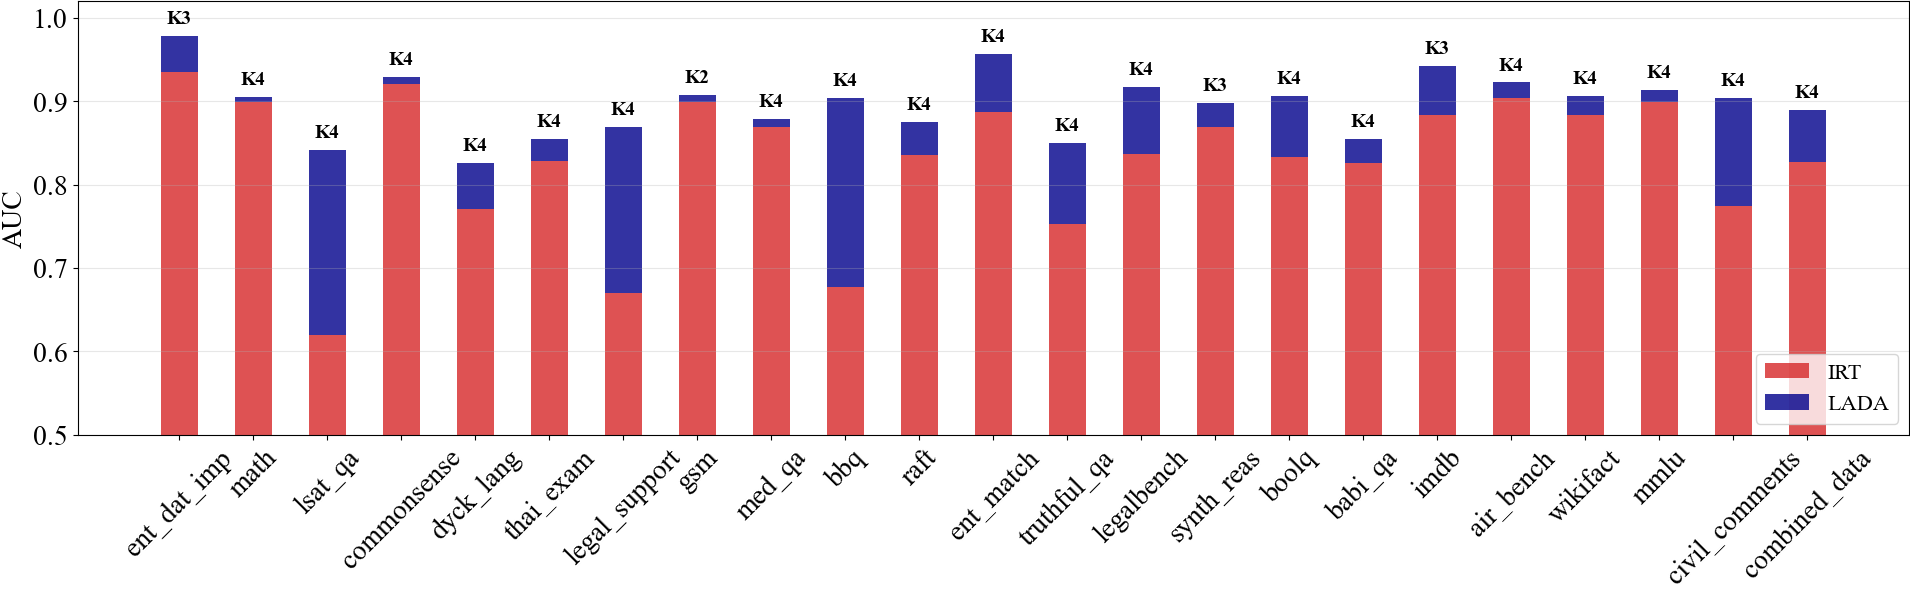

In [24]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import style
import numpy as np
import pandas as pd

# Filter out rows with missing size values
df_plot = df.dropna(subset=['size']).copy()

# Create the plot with wider figure
fig, ax = plt.subplots(figsize=(24, 6))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df_plot.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df_plot['scenario'].unique(), key=lambda x: scenario_size_mapping[x])

# Add combined_data as a separate scenario at the end
scenarios_with_combined = scenarios + ['combined_data']

# Prepare data for plotting
plot_data = []

for scenario in scenarios_with_combined:
    if scenario == 'combined_data':
        if 'df_combined' in locals() and len(df_combined) > 0:
             # Find the highest k-factor value for combined_data
            max_combined_row = df_combined.loc[df_combined['test_auc'].idxmax()]
            
            # Get IRT for combined_data (now included in the dataframe)
            irt_val = max_combined_row['irt'] if 'irt' in max_combined_row else 0
            lada_val = max_combined_row['test_auc']
            k_val = int(max_combined_row['k_factor'])
            
            plot_data.append({
                'scenario': scenario,
                'irt': irt_val,
                'lada': lada_val,
                'k_factor': k_val
            })
    else:
        df_scenario = df_plot[df_plot['scenario'] == scenario]
        if len(df_scenario) > 0:
            # Find the row with the highest LADA AUC for this scenario
            max_lada_row = df_scenario.loc[df_scenario['test_auc'].idxmax()]
            plot_data.append({
                'scenario': scenario,
                'irt': max_lada_row['irt'],
                'lada': max_lada_row['test_auc'],
                'k_factor': int(max_lada_row['k_factor'])
            })

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data)

# Plotting
if not plot_df.empty:
    # IRT Bars (Base) - Red with thinner width
    # If IRT is NaN, fill with 0
    plot_df['irt'] = plot_df['irt'].fillna(0)
    
    ax.bar(plot_df.index, plot_df['irt'], color='tab:red', label='IRT', alpha=0.8, width=0.5)

    # LADA Bars (Stacked on top) - Dark Blue with thinner width
    # Calculate gain
    gain = plot_df['lada'] - plot_df['irt']
    
    ax.bar(plot_df.index, gain, bottom=plot_df['irt'], color='darkblue', label='LADA', alpha=0.8, width=0.5)

    # Add K{dim} labels on top of bars
    for idx, row in plot_df.iterrows():
        ax.text(idx, row['lada'] + 0.01, f"K{row['k_factor']}", 
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    # Customize the plot
    ax.set_xticks(plot_df.index)
    # Create labels with scenario names, replacing entity_data_imputation with ent_dat_imp
    scenario_rename_map = {
        'entity_data_imputation': 'ent_dat_imp',
        'dyck_language_np=3': 'dyck_lang',
        'synthetic_reasoning': 'synth_reas',
        'air_bench_2024': 'air_bench',
        'entity_matching': 'ent_match',
    }
    scenario_labels = [scenario_rename_map.get(s, s) for s in plot_df['scenario']]
    ax.set_xticklabels(scenario_labels, rotation=45, ha='center', fontsize=20)
    ax.set_ylabel('AUC', fontsize=20)
    ax.set_ylim(0.5, 1.02)
    ax.tick_params(axis='y', labelsize=20)
    ax.legend(loc='lower right', fontsize=16)
    ax.grid(True, axis='y', alpha=0.3)
    
    fig.savefig('./images/lada_irt_comparison.pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data
models = ['Naive', 'Average score', 'Rasch', 'Simple LADA', 'LADA']

# Calculate standard errors for LADA and Rasch
# For LADA: use the std of test_auc across all k-factors for each scenario, then average
lada_std = highest_lada_df['test_auc'].std()
lada_se = lada_std / np.sqrt(len(highest_lada_df))

# For Rasch: use the std of irt values
irt_std = df_irt['irt'].std()
irt_se = irt_std / np.sqrt(len(df_irt))

# For Simple LADA: calculate the average and std of combined_data test_auc values
combined_data_avg = df_combined[df_combined['scenario'] == 'combined_data']['test_auc'].mean()
simple_lada_std = df_combined[df_combined['scenario'] == 'combined_data']['test_auc'].std()
simple_lada_se = simple_lada_std / np.sqrt(len(df_combined[df_combined['scenario'] == 'combined_data']))

# Setup data with values and standard errors
auc_values = [0.50, 0.66, irt_avg, combined_data_avg, lada_avg]
errors = [0.0, 0.0, irt_se, simple_lada_se, lada_se]

# 2. Create Figure
# Using a wide, short aspect ratio to match the screenshot
fig, ax = plt.subplots(figsize=(10, 3))

# 3. Plot Bars
# Hex color #b57fb3 approximates the purple in the image
bars = ax.bar(models, auc_values, color='#b57fb3', width=0.8)

# 4. Formatting Axes
# Set Y-axis limits from 0.4 to 1.0 to match the crop in the image
ax.set_ylim(0.41, 1.0)

# Labels with larger font sizes
ax.set_ylabel('AUC on Test Set', fontsize=16, labelpad=5)
ax.set_xlabel('Response Model', fontsize=16, labelpad=5)

# 5. Add Value Labels on Top of Bars
for idx, (bar, value) in enumerate(zip(bars, auc_values)):
    height = bar.get_height()
    error_val = errors[idx]
    
    # Show value with error bars for non-zero errors
    if error_val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                f'{value:.2f}', ha='center', va='bottom', fontsize=16)
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                f'{value:.2f}', ha='center', va='bottom', fontsize=16)

# 6. Final Polish
# Ensure ticks are on both sides (if desired) or standard style
ax.tick_params(axis='both', which='major', labelsize=16)
fig.savefig('./images/lada_performance.pdf', bbox_inches='tight')
# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

NameError: name 'irt_avg' is not defined